<a href="https://colab.research.google.com/github/anushkap0/RetinaGuard/blob/main/RetinaGuard_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless tqdm -q


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

In [ ]:

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/project/archive (12).zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
DATA_DIR = r"/content/dataset/colored_images"

IMG_SIZE   = 224
BATCH      = 16
SEED       = 42
EPOCHS_P1  = 10
EPOCHS_P2  = 40

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))
])
print('Classes found:', CLASS_NAMES)
assert len(CLASS_NAMES) == 5, f'Expected 5 classes, found {len(CLASS_NAMES)}. Check DATA_DIR path.'

Classes found: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [ ]:
paths, labels = [], []
for idx, cls in enumerate(CLASS_NAMES):
    folder = Path(DATA_DIR) / cls
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG']:
        for f in folder.glob(ext):
            paths.append(str(f))
            labels.append(idx)

paths  = np.array(paths)
labels = np.array(labels)
print(f'Total: {len(paths)} images')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {c}: {np.sum(labels==i)}')

X_train, X_val, y_train, y_val = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)
print(f'\nTrain: {len(X_train)} | Val: {len(X_val)}')

Total: 3662 images
  Mild: 370
  Moderate: 999
  No_DR: 1805
  Proliferate_DR: 295
  Severe: 193

Train: 2929 | Val: 733


In [ ]:

def crop_image_from_gray(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if img[np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
        return img
    r = img[:,:,0][np.ix_(mask.any(1), mask.any(0))]
    g = img[:,:,1][np.ix_(mask.any(1), mask.any(0))]
    b = img[:,:,2][np.ix_(mask.any(1), mask.any(0))]
    return np.stack([r, g, b], axis=-1)

def ben_graham_np(img_bytes, sigmaX=10, size=224):
    try:
        nparr = np.frombuffer(img_bytes.numpy(), np.uint8)
        img   = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except:
        return np.zeros((size, size, 3), dtype=np.float32)

    if img is None or img.size == 0:
        return np.zeros((size, size, 3), dtype=np.float32)

    img     = crop_image_from_gray(img)
    img     = cv2.resize(img, (size, size))
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX)
    img     = cv2.addWeighted(img, 4, blurred, -4, 128)
    img     = np.clip(img, 0, 255).astype(np.uint8)

    h, w    = img.shape[:2]
    cx, cy  = w // 2, h // 2
    r       = int(min(cx, cy) * 0.9)
    circle  = np.zeros((h, w), np.uint8)
    cv2.circle(circle, (cx, cy), r, 1, thickness=-1)
    img     = cv2.bitwise_and(img, img, mask=circle)

    return img.astype(np.float32) / 255.0

def load_and_preprocess(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.py_function(
        func=lambda b: ben_graham_np(b),
        inp=[raw], Tout=tf.float32
    )
    img.set_shape([224, 224, 3])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.random_saturation(img, 0.8, 1.2)

    img   = img * 2.0 - 1.0   # [-1, 1]
    label = tf.one_hot(label, len(CLASS_NAMES))
    return img, label

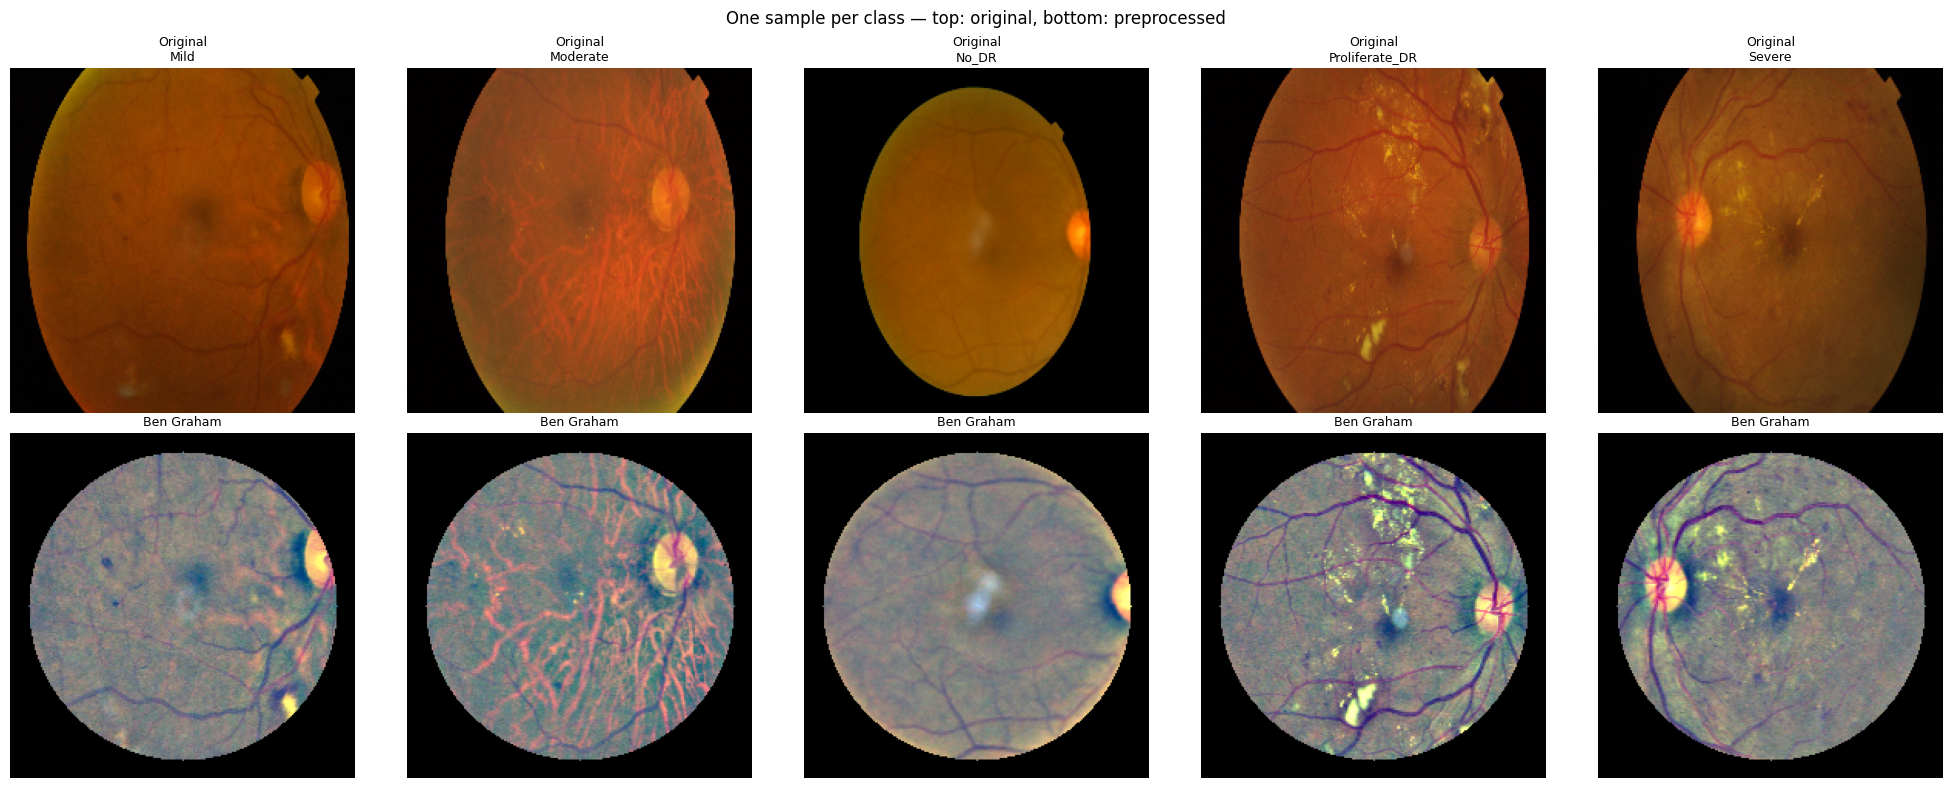

If bottom row looks HIGH CONTRAST with visible vessels → preprocessing OK ✅
If bottom row looks dark/gray/blank → something went wrong ❌


In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for cls_idx in range(5):
    cls_paths = [p for p, l in zip(X_train, y_train) if l == cls_idx]
    raw_bytes = tf.io.read_file(cls_paths[0])

    raw_img  = cv2.imdecode(
        np.frombuffer(raw_bytes.numpy(), np.uint8), cv2.IMREAD_COLOR
    )
    raw_img  = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    processed = ben_graham_np(raw_bytes)

    axes[0, cls_idx].imshow(raw_img)
    axes[0, cls_idx].set_title(f'Original\n{CLASS_NAMES[cls_idx]}', fontsize=9)
    axes[0, cls_idx].axis('off')

    axes[1, cls_idx].imshow(processed)
    axes[1, cls_idx].set_title('Ben Graham', fontsize=9)
    axes[1, cls_idx].axis('off')

plt.suptitle('One sample per class — top: original, bottom: preprocessed', fontsize=12)
plt.tight_layout()
plt.show()
print("If bottom row looks HIGH CONTRAST with visible vessels → preprocessing OK ✅")
print("If bottom row looks dark/gray/blank → something went wrong ❌")

In [ ]:
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED)
    .map(lambda x, y: load_and_preprocess(x, y, augment=True),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(lambda x, y: load_and_preprocess(x, y, augment=False),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

for imgs, lbls in val_ds.take(1):
    print(f"✅ Shape: {imgs.shape}")
    print(f"✅ Range: [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")

✅ Shape: (16, 224, 224, 3)
✅ Range: [-1.00, 1.00]


In [ ]:
raw_w = compute_class_weight('balanced',
        classes=np.unique(y_train), y=y_train)
class_weights = {i: min(float(w), 2.5) for i, w in enumerate(raw_w)}
print("Class weights:", class_weights)

Class weights: {0: 1.979054054054054, 1: 0.7331664580725907, 2: 0.4056786703601108, 3: 2.4822033898305085, 4: 2.5}


In [ ]:
base = tf.keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False,
    input_shape=(224, 224, 3)
)
base.trainable = False

inp = tf.keras.Input(shape=(224, 224, 3))
x   = base(inp, training=False)
x   = tf.keras.layers.GlobalAveragePooling2D()(x)
x   = tf.keras.layers.BatchNormalization()(x)
x   = tf.keras.layers.Dense(512, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x   = tf.keras.layers.Dropout(0.5)(x)
x   = tf.keras.layers.Dense(256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x   = tf.keras.layers.Dropout(0.3)(x)
out = tf.keras.layers.Dense(5, activation='softmax')(x)
model = tf.keras.Model(inp, out)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,843,176 (18.48 MB)

 Trainable params: 791,045 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("\n=== PHASE 1: Head Warmup ===")
history_p1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_P1,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, min_delta=0.005
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        )
    ]
)


=== PHASE 1: Head Warmup ===
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.2660 - auc: 0.5870 - loss: 2.1312 - val_accuracy: 0.1010 - val_auc: 0.5787 - val_loss: 1.7068 - learning_rate: 0.0010
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.2492 - auc: 0.5715 - loss: 1.7780 - val_accuracy: 0.1446 - val_auc: 0.4681 - val_loss: 1.7215 - learning_rate: 0.0010
Epoch 3/10
 90/184 ━━━━━━━━━━━━━━━━━━━━ 1:57 1s/step - accuracy: 0.3062 - auc: 0.6202 - loss: 1.6107

KeyboardInterrupt: 

In [ ]:

print("\n=== PHASE 2: Fine-tuning ===")
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_p2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_P2,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, min_delta=0.001
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-8, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'retina_best_v5.keras',
            monitor='val_loss',
            save_best_only=True, mode='min'
        )
    ]
)


=== PHASE 2: Fine-tuning ===
Epoch 1/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.2844 - auc: 0.6137 - loss: 1.6440 - val_accuracy: 0.1023 - val_auc: 0.6411 - val_loss: 1.5896 - learning_rate: 2.0000e-05
Epoch 2/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.2977 - auc: 0.6205 - loss: 1.6086 - val_accuracy: 0.1733 - val_auc: 0.6715 - val_loss: 1.6097 - learning_rate: 2.0000e-05
Epoch 3/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.3148 - auc: 0.6326 - loss: 1.6017 - val_accuracy: 0.1487 - val_auc: 0.6627 - val_loss: 1.6367 - learning_rate: 2.0000e-05
Epoch 4/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.3226 - auc: 0.6407 - loss: 1.5857 - val_accuracy: 0.2633 - val_auc: 0.7113 - val_loss: 1.6487 - learning_rate: 2.0000e-05
Epoch 5/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3262 - auc: 0.6352 - loss: 1.5854
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
184/184 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/st

In [ ]:
# ═══════════════════════════════════════════
# CELL 11 — Evaluate
# ═══════════════════════════════════════════
loss, acc, auc = model.evaluate(val_ds)
print(f"\nVal Accuracy : {acc*100:.2f}%")
print(f"Val AUC      : {auc:.4f}")

all_preds, all_true = [], []
for imgs, lbls in val_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_true.extend(np.argmax(lbls.numpy(), axis=1))

kappa = cohen_kappa_score(all_true, all_preds, weights='quadratic')
print(f"Kappa        : {kappa:.4f}")
print("\nReport:")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
import seaborn as sns
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix — {acc*100:.1f}% accuracy')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()